# Parameters

In [1]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
from Modules.SHAPClassifierModule import *
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]

# Using MICE imputation for missing data

In [2]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)

# Drop the 'id' column if it exists
covid_train.drop(columns=['subject_id', 'hadm_id'], inplace=True, errors='ignore')
covid_test.drop(columns=['subject_id', 'hadm_id'], inplace=True, errors='ignore')

shap.initjs()

In [3]:
features2remove = [
    "died_in_stay",
    "COVID",
    "charlson_comorbidity_index"
]  # Add the features to remove

In [4]:
helper = ShapHelperClassifier(covid_train,covid_test,"died")
helper.remove_features(features2remove)

2026-02-19 18:15:00,186 - Modules.SHAPClassifierModule - INFO - Train size: 2348, Test size: 1007


### Search the best model

In [5]:
models = ["xgboost", "logreg", "randomForest"]
values = []
params_list = []

In [6]:
_, params, value = helper.optimize_hyperparameters(model_name="xgboost")
values.append(value)
params_list.append(params)

[I 2026-02-19 18:15:00,277] A new study created in memory with name: no-name-e2a1a339-1f1b-484b-8b47-eabaa4aaceb7
[I 2026-02-19 18:15:00,857] Trial 0 finished with value: 0.5221445221445221 and parameters: {'learning_rate': 0.26097501923477817, 'n_estimators': 839, 'gamma': 0.17958604473540177, 'reg_alpha': 0.014043337194321603, 'reg_lambda': 0.3188949042621284, 'scale_pos_weight': 1}. Best is trial 0 with value: 0.5221445221445221.
[I 2026-02-19 18:15:01,546] Trial 1 finished with value: 0.6043737574552683 and parameters: {'learning_rate': 0.11382849698434909, 'n_estimators': 910, 'gamma': 0.25942774524187845, 'reg_alpha': 0.6128769227360643, 'reg_lambda': 0.4560448589028161, 'scale_pos_weight': 3}. Best is trial 1 with value: 0.6043737574552683.
[I 2026-02-19 18:15:01,932] Trial 2 finished with value: 0.5495376486129459 and parameters: {'learning_rate': 0.07543844888084202, 'n_estimators': 133, 'gamma': 0.29305567159402707, 'reg_alpha': 0.48369675698811165, 'reg_lambda': 0.4026671605

In [7]:
_, params, value = helper.optimize_hyperparameters(model_name="logreg")
values.append(value)
params_list.append(params)

[I 2026-02-19 18:17:16,436] A new study created in memory with name: no-name-30561a98-33da-4c6d-ae39-af5748ba5e08
[I 2026-02-19 18:17:16,468] Trial 0 finished with value: 0.5880681818181818 and parameters: {'solver_penalty': 'liblinear_l2', 'C': 0.34087488170746, 'max_iter': 175, 'fit_intercept': False, 'class_weight': 'balanced', 'warm_start': True}. Best is trial 0 with value: 0.5880681818181818.
[I 2026-02-19 18:17:16,498] Trial 1 finished with value: 0.615625 and parameters: {'solver_penalty': 'lbfgs_none', 'C': 1.7985022258319987, 'max_iter': 691, 'fit_intercept': True, 'class_weight': 'balanced', 'warm_start': False}. Best is trial 1 with value: 0.615625.
[I 2026-02-19 18:17:16,513] Trial 2 finished with value: 0.5371702637889688 and parameters: {'solver_penalty': 'lbfgs_l2', 'C': 0.09540314240755703, 'max_iter': 482, 'fit_intercept': True, 'class_weight': None, 'warm_start': False}. Best is trial 1 with value: 0.615625.
[I 2026-02-19 18:17:16,527] Trial 3 finished with value: 0.

In [9]:
_, params, value = helper.optimize_hyperparameters(model_name="randomForest")
values.append(value)
params_list.append(params)

[I 2026-02-19 18:17:35,371] A new study created in memory with name: no-name-f40f34e0-d6b8-4e25-aa28-46945cd1825d
[I 2026-02-19 18:17:37,086] Trial 0 finished with value: 0.509090909090909 and parameters: {'n_estimators': 257, 'max_depth': None, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.509090909090909.
[I 2026-02-19 18:17:38,167] Trial 1 finished with value: 0.33015873015873015 and parameters: {'n_estimators': 385, 'max_depth': 5, 'min_samples_split': 5, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.509090909090909.
[I 2026-02-19 18:17:40,657] Trial 2 finished with value: 0.4789473684210526 and parameters: {'n_estimators': 424, 'max_depth': 20, 'min_samples_split': 7, 'min_samples_leaf': 2, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.509090909090909.
[I 2026-02-19 18:17:41,646] Trial 3 finished with value: 0.2931596091205212 and parameters: {'n_estimators': 417, 'max_depth': 5, 'min_

In [10]:
idx_best = values.index(max(values))
best_model = models[idx_best]
best_params = params_list[idx_best]

## Shap

In [11]:
if best_model == "logreg":

    solver_penalty = best_params["solver_penalty"]
    solver, penalty = solver_penalty.split("_")
    best_params["solver"] = solver
    best_params["penalty"] = penalty
    del best_params["solver_penalty"]

In [12]:
best_model

'xgboost'

In [13]:
best_params

{'learning_rate': 0.055107375358922225,
 'n_estimators': 597,
 'gamma': 0.28108123041747574,
 'reg_alpha': 0.9329500640698715,
 'reg_lambda': 0.9740568473664054,
 'scale_pos_weight': 15}

In [14]:
best_model, best_params = ('xgboost', {'learning_rate': 0.03194788423314631,
 'n_estimators': 855,
 'gamma': 0.15986032691615765,
 'reg_alpha': 0.7169178389895312,
 'reg_lambda': 0.5826947399857607,
 'scale_pos_weight': 12})

Accuracy:  0.7865
Precision: 0.5613
Recall:    0.6877
F1 Score:  0.6181


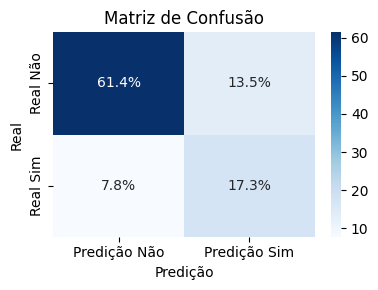

In [15]:
helper.train_single_model(best_params, model_name=best_model)
helper.print_metrics()
helper.show_confusion_matrix()

In [16]:
helper.compute_shap_values()

 97%|=================== | 974/1007 [00:18<00:00]       

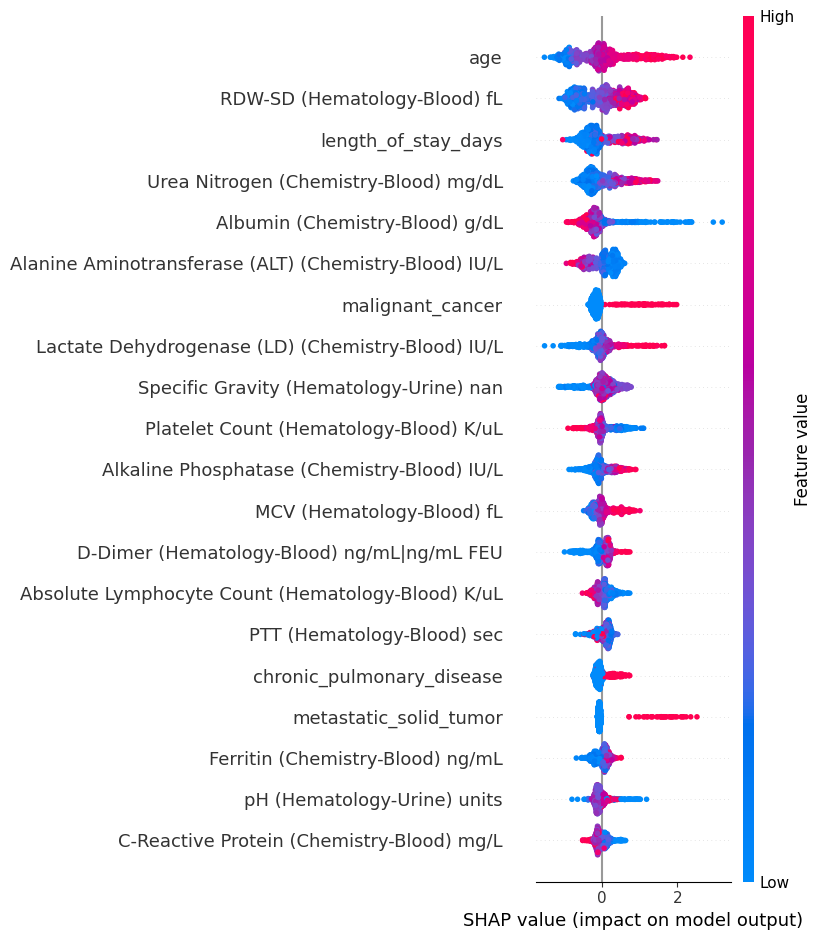

<Figure size 640x480 with 0 Axes>

In [18]:
helper.plot_shap_summary(verbosity=2)

<Figure size 1000x700 with 0 Axes>

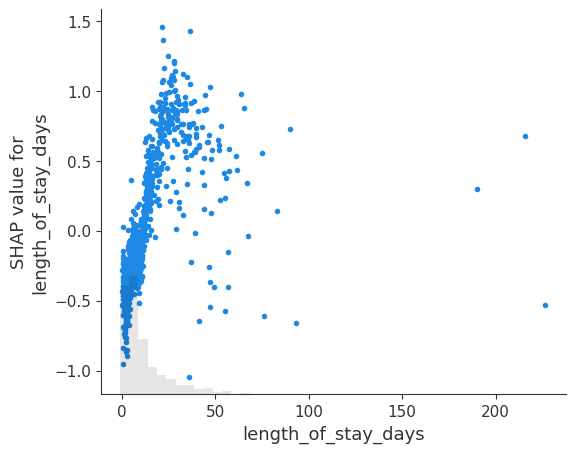

<Figure size 640x480 with 0 Axes>

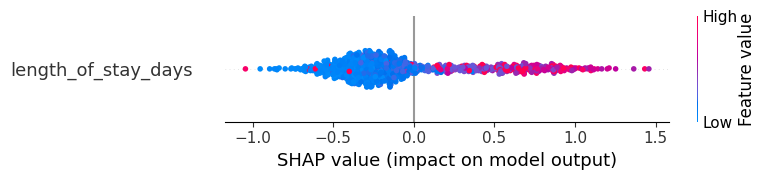

<Figure size 640x480 with 0 Axes>

In [19]:
rank = 3

helper.plot_shap_feature(rank=rank)
helper.plot_shap_summary(rank=rank)

In [20]:
helper.get_top_features(n=20)

['age',
 'RDW-SD_Hematology_Blood_fL',
 'length_of_stay_days',
 'Urea Nitrogen_Chemistry_Blood_mg/dL',
 'Albumin_Chemistry_Blood_g/dL',
 'Alanine Aminotransferase (ALT)_Chemistry_Blood_IU/L',
 'malignant_cancer',
 'Lactate Dehydrogenase (LD)_Chemistry_Blood_IU/L',
 'Specific Gravity_Hematology_Urine_nan',
 'Platelet Count_Hematology_Blood_K/uL',
 'Alkaline Phosphatase_Chemistry_Blood_IU/L',
 'MCV_Hematology_Blood_fL',
 'D-Dimer_Hematology_Blood_ng/mL|ng/mL FEU',
 'Absolute Lymphocyte Count_Hematology_Blood_K/uL',
 'PTT_Hematology_Blood_sec',
 'chronic_pulmonary_disease',
 'metastatic_solid_tumor',
 'Ferritin_Chemistry_Blood_ng/mL',
 'pH_Hematology_Urine_units',
 'C-Reactive Protein_Chemistry_Blood_mg/L']